# Imports

In [1]:
from pySVA.sva_core import *
from pySVA.sva_calc import *

In [2]:
import dfm_tools as dfmt
import numpy as np
import xarray as xr

# Data description

In [3]:
data_description = {
    "nfaces": "mesh2d_nFaces",
    "depth": "mesh2d_nLayers",
    "time" : "time"
}

In [4]:
import numpy as np

# Set up dask cluster

In [5]:
from dask_jobqueue import SLURMCluster
from dask.distributed import Client

In [6]:
n_cores = 1
n_processes = 4
mem_lim = str(int(np.floor(224/(n_cores*n_processes))))+'GB' # 336 for genoa

In [7]:
cluster = SLURMCluster(name='dask-cluster',
                       cores=n_cores,
                       memory=mem_lim,
                       processes=n_processes,
                       interface='ib0',
                       queue='rome',
                       walltime='04:00:00',
                       asynchronous=0)

INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.diskutils:Found stale lock file and directory '/scratch-local/mgeraeds/dask-scratch-space/scheduler-qnw1jign', purging
INFO:distributed.scheduler:  Scheduler at: tcp://172.22.63.190:44205
INFO:distributed.scheduler:  dashboard at:  http://172.22.63.190:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle


In [8]:
print(cluster.job_script())

#!/usr/bin/env bash

#SBATCH -J dask-worker
#SBATCH -p rome
#SBATCH -n 1
#SBATCH --cpus-per-task=1
#SBATCH --mem=53G
#SBATCH -t 04:00:00

/home/mgeraeds/.conda/envs/dfm_proc_env/bin/python -m distributed.cli.dask_worker tcp://172.22.63.190:44205 --name dummy-name --nthreads 0 --memory-limit 13.04GiB --nworkers 4 --nanny --death-timeout 60 --interface ib0



In [9]:
cluster.scale(1)

In [10]:
client = Client(cluster)

INFO:distributed.scheduler:Receive client connection: Client-55fdbc9a-dd50-11ee-b8cc-00001029fe80
INFO:distributed.core:Starting established connection to tcp://172.22.63.190:36852


In [11]:
client

Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: http://172.22.63.190:8787/status,
Dashboard: http://172.22.63.190:8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://172.22.63.190:44205,Workers: 0
Dashboard: http://172.22.63.190:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


INFO:distributed.scheduler:Register worker <WorkerState 'tcp://172.22.57.125:33479', name: dask-cluster-0-3, status: init, memory: 0, processing: 0>
INFO:distributed.scheduler:Starting worker compute stream, tcp://172.22.57.125:33479
INFO:distributed.core:Starting established connection to tcp://172.22.57.125:54138
INFO:distributed.scheduler:Register worker <WorkerState 'tcp://172.22.57.125:33671', name: dask-cluster-0-0, status: init, memory: 0, processing: 0>
INFO:distributed.scheduler:Starting worker compute stream, tcp://172.22.57.125:33671
INFO:distributed.core:Starting established connection to tcp://172.22.57.125:54140
INFO:distributed.scheduler:Register worker <WorkerState 'tcp://172.22.57.125:32941', name: dask-cluster-0-1, status: init, memory: 0, processing: 0>
INFO:distributed.scheduler:Starting worker compute stream, tcp://172.22.57.125:32941
INFO:distributed.core:Starting established connection to tcp://172.22.57.125:54144
INFO:distributed.scheduler:Register worker <Worke

# Load dataset

In [12]:
file_nc = r'/projects/0/einf1300/saltis-wp3-1/C_Work/04_RMD_2022/computations/B04/B04_2022_jun23-24/ZUNO-zd_dflowfm_B04_jun23-24_0000_map.nc'

In [13]:
data_xr = dfmt.open_partitioned_dataset(file_nc.replace('_0000_',"_0*_"), chunks={'time':1})# "mesh2d_nFaces":50000, "mesh2d_nNodes":50000, "mesh2d_nEdges":50000})#, "mesh2d_nFaces":5000, "mesh2d_nNodes":5000, "mesh2d_nEdges":5000})

>> xu.open_dataset() with 96 partition(s): 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 : 101.45 sec
>> xu.merge_partitions() with 96 partition(s): 5.33 sec
>> some variables dropped with merging of partitions: ['mesh2d_face_x_bnd', 'mesh2d_face_y_bnd']
>> dfmt.open_partitioned_dataset() total: 106.87 sec


In [14]:
uds = data_xr

In [15]:
import xugrid as xu
import matplotlib.pyplot as plt

In [16]:
def build_face_edge_connectivity(uds):
    # First check if the provided dataset is a xu.core.wrap.UgridDataset

    if isinstance(uds, xu.core.wrap.UgridDataset):
        # > Get fill value, grid name, and dimensions
        fill_value = uds.grid.fill_value
        gridname = uds.grid.name
        dimn_faces = uds.grid.face_dimension
        dimn_maxfn = uds.grid.to_dataset().mesh2d.attrs['max_face_nodes_dimension']

        # > Get coordinate names
        coord_face_x, coord_face_y = uds.grid.to_dataset().mesh2d.attrs['node_coordinates'].replace('node', 'face').split()

        # > Get connectivity
        face_edges = uds.grid.face_edge_connectivity

        # > Make into xr.DataArray with correct sizes, dimensions, and coordinates
        face_edge_connectivity = xr.DataArray(face_edges, dims=[dimn_faces, dimn_maxfn],
                                              coords={f'{coord_face_x}': ([dimn_faces], uds[f'{coord_face_x}']),
                                                      f'{coord_face_y}': ([dimn_faces], uds[f'{coord_face_y}'])},
                                              attrs={'cf_role': 'face_edge_connectivity', 'start_index': 0,
                                                     '_FillValue': fill_value}, name=f'{gridname}_face_edges')

        
    else:
        raise IOError("Please provide xu.core.wrap.UgridDataset to be able to automatically derive connectivities of the unstructured grid.")

    return face_edge_connectivity


In [17]:
def build_edge_node_connectivity(uds):

    # > Get fill value, grid name and dimensions 
    fill_value = uds.grid.fill_value
    gridname = uds.grid.name
    dimn_edges = uds.grid.edge_dimension

    # > Get coordinate names
    coord_edge_x, coord_edge_y = uds.grid.to_dataset().mesh2d.attrs['node_coordinates'].replace('node', 'edge').split()

    # > Determine dimension name
    dimn_maxen = f'{gridname}_nMax_edge_nodes'

    # > Get connectivity
    edge_nodes = uds.grid.edge_node_connectivity

    # > Make into xr.DataArray with correct sizes, dimensions, and coordinates
    edge_node_connectivity = xr.DataArray(data=edge_nodes, dims=[dimn_edges, dimn_maxen], coords={f'{coord_edge_x}':([dimn_edges], uds[f'{coord_edge_x}']), f'{coord_edge_y}':([dimn_edges], uds[f'{coord_edge_y}'])}, attrs={'cf_role': 'edge_node_connectivity', 'start_index':0, '_FillValue':fill_value}, name=uds.grid.to_dataset().mesh2d.attrs['edge_node_connectivity'])

    return edge_node_connectivity

In [18]:

def get_all_coordinates(uds):


    if isinstance(uds, xu.core.wrap.UgridDataset):
        # > Get coordinate names
        coord_face_x, coord_face_y = uds.grid.to_dataset().mesh2d.attrs['node_coordinates'].replace('node', 'face').split()
        coord_edge_x, coord_edge_y = uds.grid.to_dataset().mesh2d.attrs['node_coordinates'].replace('node', 'edge').split()
        coord_node_x, coord_node_y = uds.grid.to_dataset().mesh2d.attrs['node_coordinates'].split()

        # > Get dimension names
        dimn_faces = uds.grid.face_dimension
        dimn_nodes = uds.grid.node_dimension
        dimn_edges = uds.grid.edge_dimension

        # > Get grid name
        gridname = uds.grid.name

        # > Get face coordinates
        face_array = np.c_[uds.mesh2d_face_x, uds.mesh2d_face_y] # is NOT equal to uds.grid.face_coordinates
        face_coords = xr.DataArray(data=face_array, dims=[dimn_faces,f'{gridname}_nCartesian_coords'], coords={f'{coord_face_x}':([dimn_faces], uds[f'{coord_face_x}']), f'{coord_face_y}':([dimn_faces], uds[f'{coord_face_y}'])}, attrs={'units':'m', 'standard_name': 'projection_x_coordinate, projection_y_coordinate', 'long_name':'Characteristic coordinates of mesh face', 'bounds': 'mesh2d_face_x_bnd, mesh_face_y_bnd'})

        # > Get edge coordaintes
        edge_array = uds.grid.edge_coordinates # np.c_[uds.mesh2d_edge_x, uds.mesh2d_edge_y]
        edge_coords = xr.DataArray(data=edge_array, dims=[dimn_edges,f'{gridname}_nCartesian_coords'], coords={f'{coord_edge_x}':([dimn_edges], uds[f'{coord_edge_x}']), f'{coord_edge_y}':([dimn_edges], uds[f'{coord_edge_y}'])}, attrs={'units':'m', 'standard_name': 'projection_x_coordinate, projection_y_coordinate', 'long_name':'Characteristic coordinates of mesh face', 'bounds': 'mesh2d_face_x_bnd, mesh_face_y_bnd'})

        # > Get node coordinates
        node_array =  uds.grid.node_coordinates # np.c_[uds.mesh2d_node_x, uds.mesh2d_node_y]
        node_coords = xr.DataArray(data=node_array, dims=[dimn_nodes,f'{gridname}_nCartesian_coords'], coords={f'{coord_node_x}':([dimn_nodes], uds[f'{coord_node_x}']), f'{coord_node_y}':([dimn_nodes], uds[f'{coord_node_y}'])}, attrs={'units':'m', 'standard_name': 'projection_x_coordinate, projection_y_coordinate', 'long_name':'Characteristic coordinates of mesh node', 'bounds': 'mesh2d_node_x_bnd, mesh_node_y_bnd'})
    
    elif isinstance(uds, xu.core.wrap.UgridDataArray):
        # > Get coordinate names
        coord_face_x, coord_face_y = uds.grid.to_dataset().mesh2d.attrs['node_coordinates'].replace('node', 'face').split()
        coord_edge_x, coord_edge_y = uds.grid.to_dataset().mesh2d.attrs['node_coordinates'].replace('node', 'edge').split()
        coord_node_x, coord_node_y = uds.grid.to_dataset().mesh2d.attrs['node_coordinates'].split()

        # > Get dimension names
        dimn_faces = uds.grid.face_dimension
        dimn_nodes = uds.grid.node_dimension
        dimn_edges = uds.grid.edge_dimension

        # > Get grid name
        gridname = uds.grid.name
        
        # > Get face coordinates
        face_array = uds.grid.face_coordinates
        face_coords = xr.DataArray(data=face_array, dims=[dimn_faces,f'{gridname}_nCartesian_coords'], coords={f'{coord_face_x}':([dimn_faces], uds[f'{coord_face_x}']), f'{coord_face_y}':([dimn_faces], uds[f'{coord_face_y}'])}, attrs={'units':'m', 'standard_name': 'projection_x_coordinate, projection_y_coordinate', 'long_name':'Characteristic coordinates of mesh face', 'bounds': 'mesh2d_face_x_bnd, mesh_face_y_bnd'})

        # > Get edge coordaintes
        edge_array = uds.grid.edge_coordinates # np.c_[uds.mesh2d_edge_x, uds.mesh2d_edge_y]
        edge_coords = xr.DataArray(data=edge_array, dims=[dimn_edges,f'{gridname}_nCartesian_coords'], coords={f'{coord_edge_x}':([dimn_edges], uds[f'{coord_edge_x}']), f'{coord_edge_y}':([dimn_edges], uds[f'{coord_edge_y}'])}, attrs={'units':'m', 'standard_name': 'projection_x_coordinate, projection_y_coordinate', 'long_name':'Characteristic coordinates of mesh face', 'bounds': 'mesh2d_face_x_bnd, mesh_face_y_bnd'})

        # > Get node coordinates
        node_array =  uds.grid.node_coordinates # np.c_[uds.mesh2d_node_x, uds.mesh2d_node_y]
        node_coords = xr.DataArray(data=node_array, dims=[dimn_nodes,f'{gridname}_nCartesian_coords'], coords={f'{coord_node_x}':([dimn_nodes], uds[f'{coord_node_x}']), f'{coord_node_y}':([dimn_nodes], uds[f'{coord_node_y}'])}, attrs={'units':'m', 'standard_name': 'projection_x_coordinate, projection_y_coordinate', 'long_name':'Characteristic coordinates of mesh node', 'bounds': 'mesh2d_node_x_bnd, mesh_node_y_bnd'})
    else:
        raise IOError("Please provide xu.core.wrap.UgridDataset or xu.core.wrap.UgridDataArray to be able to automatically derive connectivities of the unstructured grid.")

    return face_coords, edge_coords, node_coords

In [19]:
def calculate_unit_normal_vectors(uds, **kwargs):

    # > Get dimensions, gridname, and coordinates
    dimn_edges = uds.grid.edge_dimension
    dimn_nodes = uds.grid.node_dimension
    fill_value = uds.grid.fill_value
    gridname = uds.grid.name

    varname_unvs = f'{gridname}_unvs'

    # > See if flow area is already in the variables
    if varname_unvs in uds.variables:
        print(f'Unit normal vectors on edges already present Dataset in variable {varname_unvs}.')
        return uds[varname_unvs]

    else:
        # > Get edge coordinate names
        coord_edge_x, coord_edge_y = uds.grid.to_dataset().mesh2d.attrs['node_coordinates'].replace('node', 'edge').split()

        # > Get kwargs
        edge_node_coords = kwargs.get('edge_node_coords')
        # face_edges = kwargs.get('face_edges')

        # > See if node-edge connectivity is given as a kwarg. If not, reconstruct it
        if 'edge_node_coords' in kwargs:
            pass
        else:
            # > Get the node-edge connectivity
            edge_nodes = build_edge_node_connectivity(uds)

            # > Build the node_coords
            _, _, node_coords = get_all_coordinates(uds) # just get the node_coords

            # > Get the coordinates of all nodes belonging to an edge
            edge_node_coords = xr.where(edge_nodes!=fill_value, node_coords.isel({dimn_nodes:edge_nodes}), np.nan)
        
        x1 = edge_node_coords[:,0,0]
        x2 = edge_node_coords[:,1,0]
        y1 = edge_node_coords[:,0,1]
        y2 = edge_node_coords[:,1,1]
        x = x2 - x1
        y = y2 - y1
        
        nf = np.dstack([-y,x])
        
        # > Calculate the norm and divide by the norm
        unv = nf / np.linalg.norm(nf)
        edge_unvs = unv[0]
        
        # > Put it in xr.DataArray format
        edge_unvs = xr.DataArray(data=edge_unvs, dims=[dimn_edges,f'{gridname}_nCartesian_coords'], coords={f'{coord_edge_x}':([dimn_edges], uds[f'{coord_edge_x}']), f'{coord_edge_y}':([dimn_edges], uds[f'{coord_edge_y}'])})  
        uds[f'{varname_unvs}'] = edge_unvs
        
        return edge_unvs

In [20]:
dimn_maxfn = uds.ugrid.grid.to_dataset().mesh2d.attrs['max_face_nodes_dimension']
dimn_faces = uds.ugrid.grid.face_dimension
dimn_edges = uds.ugrid.grid.edge_dimension
fill_value = uds.ugrid.grid.fill_value
gridname = uds.ugrid.grid.name
dimn_maxef = f'{gridname}_nMax_edge_faces'

In [21]:
def build_edge_face_weights(uds, **kwargs):

	# Get dimension names
    dimn_maxfn = uds.ugrid.grid.to_dataset().mesh2d.attrs['max_face_nodes_dimension']
    dimn_faces = uds.ugrid.grid.face_dimension
    dimn_edges = uds.ugrid.grid.edge_dimension
    fill_value = uds.ugrid.grid.fill_value
    gridname = uds.ugrid.grid.name
    dimn_maxef = f'{gridname}_nMax_edge_faces'
	
    # > Get the edge-face connectivity
    edge_faces = xr.DataArray(uds.ugrid.grid.edge_face_connectivity, dims=(dimn_edges, dimn_maxef))
    
    if 'coords' in kwargs:
        face_coords, edge_coords, _ = kwargs['coords']
    else:
        # > Get all relevant coordinates
        face_coords, edge_coords, _ = get_all_coordinates(uds)

	# > Fill edge-face-connectivity matrix with face coordinates
    edge_face_coords = xr.where(edge_faces!=fill_value, face_coords.isel({dimn_faces:edge_faces}), np.nan)

	# > Get variables for d1 (distance between neighbouring cell faces through edge)
	# > Obtain these from the edge_face_coords dataset
    x0 = edge_face_coords.isel({f'{gridname}_nMax_edge_faces':0, f'{gridname}_nCartesian_coords':0})
    x1 = edge_face_coords.isel({f'{gridname}_nMax_edge_faces':1, f'{gridname}_nCartesian_coords':0})
    y0 = edge_face_coords.isel({f'{gridname}_nMax_edge_faces':0, f'{gridname}_nCartesian_coords':1})
    y1 = edge_face_coords.isel({f'{gridname}_nMax_edge_faces':1, f'{gridname}_nCartesian_coords':1})
    
    d1 = calculate_distance_pythagoras(x0, y0, x1, y1)
    
    # > Then get variables for d2 (distance from cell face in the first column to edge)
    x2 = edge_coords.isel({f'{gridname}_nCartesian_coords':0})
    y2 = edge_coords.isel({f'{gridname}_nCartesian_coords':1})
    d2 = calculate_distance_pythagoras(x0, y0, x2, y2)
    
    # > Calculate the weights per edge:
    w = d2 / d1
    
    return w

In [22]:
def uda_to_edges(uda, **kwargs):

    # > Get grid
    grid = uda.grid

    # > Get kwargs
    if 'coords' in kwargs:
        coords = kwargs['coords']
    else:
        coords = None

    # > Get dimension and grid names
    dimn_maxfn = grid.to_dataset().mesh2d.attrs['max_face_nodes_dimension']
    dimn_faces = grid.face_dimension
    dimn_edges = grid.edge_dimension
    fill_value = grid.fill_value
    gridname = grid.name
    dimn_maxef = f'{gridname}_nMax_edge_faces'

    # > Get the edge-face connectivity and replace fill values with -1
    edge_faces = xr.DataArray(uda.ugrid.grid.edge_face_connectivity, dims=(dimn_edges, dimn_maxef))
    edge_faces_validbool = edge_faces!=fill_value
    edge_faces = edge_faces.where(edge_faces_validbool, -1)

    # > Get the face-edge connectivity and replace fill values with -1
    face_edges = xr.DataArray(uda.ugrid.grid.face_edge_connectivity, dims=(dimn_faces, dimn_maxfn))
    face_edges_validbool = face_edges!=fill_value
    face_edges = face_edges.where(face_edges_validbool, -1)

    # # > Calculate the weights for the scalar interpolation 
    # # > first, if not given in the kwargs.
    # try: 
    #     face_weights = kwargs['face_weights']
    # except:
    #     face_weights = build_edge_face_weights(uda, coords=coords)
    
    # > Make sure the face dimension is not chunked, otherwise we will 
    # > get "PerformanceWarning: Slicing with an out-of-order index is generating x times more chunks."
    chunks = {dimn_faces:-1}
    uda = uda.chunk(chunks)

    # > Select the varname on faces in the edge-face connectivity matrix
    edge_faces_stacked = edge_faces.stack(__tmp_dim__=(dimn_edges, dimn_maxef))
    edge_var_stacked = uda.isel({dimn_faces: edge_faces_stacked})
    edge_var = edge_var_stacked.unstack("__tmp_dim__")
    # > Convert data-array back to an xu.UgridDataArray
    edge_var = xu.UgridDataArray(edge_var, grid=grid)

    # > Set fill values to nan-values
    edge_var = edge_var.where(edge_faces_validbool, np.nan)

    # > Calculate the variable on the edges, based on the face_weights
    # edge_var = face_weights * edge_var.isel({f'{dimn_maxef}': 0}) + (1 - face_weights) * edge_var.isel({f'{dimn_maxef}': 1})
    edge_var = edge_var.mean(dim = dimn_maxef)

    return edge_var
    

In [23]:
from pySVA.sva_helpers import calculate_distance_haversine, calculate_distance_pythagoras

In [24]:
from dfm_tools.xugrid_helpers import get_vertical_dimensions
dimn_layer, dimn_interfaces = get_vertical_dimensions(uds)

In [25]:
coords = get_all_coordinates(uds)

In [26]:
from pySVA.sva_helpers import compute_gradient_on_face

In [27]:
from pySVA.sva_calc import compute_advection

In [28]:
sva_obj = constructorSVA(input_file=uds)

In [29]:
sva_obj.tracer = sva_obj.ds.mesh2d_sa1

In [30]:
from pySVA.sva_calc import compute_tracer_variance

In [31]:
sva_obj.tracer_variance = compute_tracer_variance(sva_obj)

In [32]:
sva_obj.velu1 = sva_obj.ds['mesh2d_u1']

In [50]:
from pySVA.sva_helpers import uda_to_edges

In [47]:
varname='mesh2d_u1'

In [251]:
def compute_gradient_on_face(constructorSVA, uda, **kwargs):

    from dfm_tools.xugrid_helpers import get_vertical_dimensions
    
    # > Obtain uds from constructorSVA object
    uds = constructorSVA.ds

    # > Get grid
    grid = uds.grid

    # > Get dimension and grid names
    dimn_maxfn = grid.to_dataset().mesh2d.attrs['max_face_nodes_dimension']
    dimn_faces = grid.face_dimension
    dimn_edges = grid.edge_dimension
    fill_value = grid.fill_value
    gridname = grid.name
    dimn_maxef = f'{gridname}_nMax_edge_faces'
    dimn_layer, dimn_interfaces = get_vertical_dimensions(uds)

    # > Determine varname from the provided array\
    varname = uda.name

    # > Calculate the unit normal vectors if not in the dataset already
    try:
        unvs = kwargs['unvs']
    except:
        unvs = calculate_unit_normal_vectors(constructorSVA)
    
    # > Get the volume and flow area variables: check if they're in the 
    # > constructor first, then check the dataset, else throw error
    try:
        flow_area = constructorSVA.flow_area
    except:
        try:
            flow_area = uds[f'{gridname}_au'] # todo: extend to more arbitrary names in later stage
        except: 
            raise NameError('Could not retrieve the flow area, which is necessary for the gradient \
                             calculation. Please provide volume variable in the constructor or in the underlying dataset.')
    
    try:
        volume = constructorSVA.volume
    except:
        try:
            volume = uds[f'{gridname}_vol1']# todo: extend to more arbitrary names in later stage
        except:
            raise NameError('Could not retrieve the volume of the cells, which is necessary for the gradient \
                             calculation. Please provide volume variable in the constructor or in the underlying dataset.')

    # > Get the edge-face connectivity and replace fill values with -1
    edge_faces = xr.DataArray(uds.ugrid.grid.edge_face_connectivity, dims=(dimn_edges, dimn_maxef))
    edge_faces_validbool = edge_faces!=fill_value
    edge_faces = edge_faces.where(edge_faces_validbool, -1)
        
    # > Get the face-edge connectivity and replace fill values with -1
    face_edges = build_face_edge_connectivity(uds)
    face_edges_validbool = face_edges!=fill_value
    face_edges = face_edges.where(face_edges_validbool, -1)
    face_edges_stacked = face_edges.stack(__tmp_dim__=(dimn_faces, dimn_maxfn))

    # > Get the unit normal vectors (nf) also in the face-edges matrix
    fe_nfs = xr.where(face_edges!=fill_value, unvs.isel({dimn_edges:face_edges}), np.nan)

	# > Determine if we're looking at a velocity value u1 or u0
    # > Because these are vector quantities in the direction of the normal vector,
    # > to get to the final vector, we have to multiply u1/u0 by the normal vector
    # > first. Also, we need to check their sign for every edge.
    if dimn_edges in uda.dims:
        # > Make sure the edge dimension is not chunked, otherwise we will 
        # > get "PerformanceWarning: Slicing with an out-of-order index is generating x times more chunks."
        chunks = {dimn_edges:-1}
        uda = uda.chunk(chunks)

        # > Fill the face-edges matrix with the varname
        # > Do this via stack and unstack since 2D indexing does not
        # > properly work in dask yet: https://github.com/dask/dask/pull/10237
        edge_var_stacked = uda.isel({dimn_edges: face_edges_stacked})
        edge_var = edge_var_stacked.unstack("__tmp_dim__")
        # > Convert data-array back to an xu.UgridDataArray
        edge_var = xu.UgridDataArray(edge_var, grid=grid)

        # > Fill face_edge matrix with flow area data
        flow_area = flow_area.chunk(chunks)
        edge_au_stacked = flow_area.isel({dimn_edges:face_edges_stacked})
        edge_au = edge_au_stacked.unstack("__tmp_dim__")

        # > Multiply the variable with the edge area (flow area), multiply by the 
        # > "flipped boolean" and the unit normal vector, and sum (dimension: faces)
        face_vars = (edge_var * edge_au * fe_nfs).sum(dim=dimn_maxfn, keep_attrs=True)
        
        # > Multiply the total result with (1/cell volume) (dimension: faces)
        gradient = (1/volume) * face_vars
        uds[f'{varname}_gradient'] = gradient
        
        return gradient

    else: 
        raise ValueError('This function only supports the calculation of gradients at face location, \
                         based on data on edges. Please supply a variable that is located on the edges.')


In [33]:
sva_obj.tracer = uda_to_edges(sva_obj.tracer)

/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/xarray/core/dataset.py:5557: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array.reshape(shape)Explictly passing ``limit`` to ``reshape`` will also silence this warning
    >>> array.reshape(shape, limit='128 MiB')
  result = result._unstack_full_reindex(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/xarray/core/dataset.py:5557: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creat

In [34]:
sva_obj.flow_area = uds['mesh2d_au']
sva_obj.volume = uds['mesh2d_vol1']

In [82]:

def compute_gradient_on_face(constructorSVA, uda, **kwargs):

    from dfm_tools.xugrid_helpers import get_vertical_dimensions
    
    # > Obtain uds from constructorSVA object
    uds = constructorSVA.ds

    # > Get grid
    grid = uds.grid

    # > Get dimension and grid names
    dimn_maxfn = grid.to_dataset().mesh2d.attrs['max_face_nodes_dimension']
    dimn_faces = grid.face_dimension
    dimn_edges = grid.edge_dimension
    fill_value = grid.fill_value
    gridname = grid.name
    dimn_maxef = f'{gridname}_nMax_edge_faces'
    dimn_layer, dimn_interfaces = get_vertical_dimensions(uds)
    dimn_cart = f'{gridname}_nCartesian_coords'

    # > Determine varname from the provided array\
    varname = uda.name

    # > Calculate the unit normal vectors if not in the dataset already
    try:
        unvs = kwargs['unvs']
    except:
        unvs = calculate_unit_normal_vectors(constructorSVA)
    
    # > Get the volume and flow area variables: check if they're in the 
    # > constructor first, then check the dataset, else throw error
    try:
        flow_area = constructorSVA.flow_area
    except:
        try:
            flow_area = uds[f'{gridname}_au'] # todo: extend to more arbitrary names in later stage
        except: 
            raise NameError('Could not retrieve the flow area, which is necessary for the gradient \
                             calculation. Please provide volume variable in the constructor or in the underlying dataset.')
    
    try:
        volume = constructorSVA.volume
    except:
        try:
            volume = uds[f'{gridname}_vol1']# todo: extend to more arbitrary names in later stage
        except:
            raise NameError('Could not retrieve the volume of the cells, which is necessary for the gradient \
                             calculation. Please provide volume variable in the constructor or in the underlying dataset.')

    # > Get the edge-face connectivity and replace fill values with -1
    edge_faces = xr.DataArray(uds.ugrid.grid.edge_face_connectivity, dims=(dimn_edges, dimn_maxef))
    edge_faces_validbool = edge_faces!=fill_value
    edge_faces = edge_faces.where(edge_faces_validbool, -1)
        
    # > Get the face-edge connectivity and replace fill values with -1
    face_edges = build_face_edge_connectivity(uds)
    face_edges_validbool = face_edges!=fill_value
    face_edges = face_edges.where(face_edges_validbool, -1)
    face_edges_stacked = face_edges.stack(__tmp_dim__=(dimn_faces, dimn_maxfn))

    # > Get the unit normal vectors (nf) also in the face-edges matrix
    fe_nfs = xr.where(face_edges!=fill_value, unvs.isel({dimn_edges:face_edges}), np.nan)

    # // 2. See if the normal vectors are pointing out of the cell. If not, flip them.
    # > Calculate distance vectors
    dv = calculate_distance_vectors(uds)
    # > Calculate the dot product between the calculated normal vectors and the distance vector for each face
    i_nfs = xr.dot(fe_nfs, dv, dims=[dimn_cart])
    # > if the product < 1, multiply by -1 to get an outwards facing normal vector, and update the variable
    fe_nfs = xr.where(i_nfs > 0, fe_nfs, fe_nfs * -1)

	# > Determine if we're looking at a velocity value u1 or u0
    # > Because these are vector quantities in the direction of the normal vector,
    # > to get to the final vector, we have to multiply u1/u0 by the normal vector
    # > first. Also, we need to check their sign for every edge.
    if dimn_edges in uda.dims:
        # > Make sure the edge dimension is not chunked, otherwise we will 
        # > get "PerformanceWarning: Slicing with an out-of-order index is generating x times more chunks."
        chunks = {dimn_edges:-1}
        uda = uda.chunk(chunks)

        # > Fill the face-edges matrix with the varname
        # > Do this via stack and unstack since 2D indexing does not
        # > properly work in dask yet: https://github.com/dask/dask/pull/10237
        edge_var_stacked = uda.isel({dimn_edges: face_edges_stacked})
        edge_var = edge_var_stacked.unstack("__tmp_dim__")
        # > Convert data-array back to an xu.UgridDataArray
        edge_var = xu.UgridDataArray(edge_var, grid=grid)

        # > Fill face_edge matrix with flow area data
        flow_area = flow_area.chunk(chunks)
        edge_au_stacked = flow_area.isel({dimn_edges:face_edges_stacked})
        edge_au = edge_au_stacked.unstack("__tmp_dim__")

        # > Multiply the variable with the edge area (flow area), multiply by the 
        # > "flipped boolean" and the unit normal vector, and sum (dimension: faces)
        face_vars = (edge_var * edge_au * fe_nfs).sum(dim=dimn_maxfn, keep_attrs=True)
        
        # > Multiply the total result with (1/cell volume) (dimension: faces)
        gradient = (1/volume) * face_vars
        uds[f'{varname}_gradient'] = gradient
        
        return gradient

    else: 
        raise ValueError('This function only supports the calculation of gradients at face location, \
                         based on data on edges. Please supply a variable that is located on the edges.')


In [41]:

def calculate_unit_normal_vectors(constructorSVA, **kwargs):
    
    # First check if the provided dataset is a xu.core.wrap.UgridDataset
    uds = constructorSVA.ds

    if isinstance(uds, xu.core.wrap.UgridDataset):
        # > Get dimensions, gridname, and coordinates
        dimn_edges = uds.grid.edge_dimension
        dimn_nodes = uds.grid.node_dimension
        fill_value = uds.grid.fill_value
        gridname = uds.grid.name
        dimn_maxen = f'{gridname}_nMax_edge_nodes'
        dimn_cart = f'{gridname}_nCartesian_coords'

        varname_unvs = f'{gridname}_unvs'

        # > See if flow area is already in the variables
        try:
            unvs = constructorSVA._unvs
            print(f'Unit normal vectors on edges already present Dataset in variable {unvs.name}.')

        except:
            if varname_unvs in uds.variables:
                print(f'Unit normal vectors on edges already present Dataset in variable {varname_unvs}.')
                return uds[varname_unvs]
            else:
                # > Get edge coordinate names
                coord_edge_x, coord_edge_y = uds.grid.to_dataset().mesh2d.attrs['node_coordinates'].replace('node', 'edge').split()

                # > Get kwargs
                edge_node_coords = kwargs.get('edge_node_coords')
                # face_edges = kwargs.get('face_edges')

                # > See if node-edge connectivity is given as a kwarg. If not, reconstruct it
                if 'edge_node_coords' in kwargs:
                    pass
                else:
                    # > Get the node-edge connectivity
                    edge_nodes = build_edge_node_connectivity(uds)

                    # > Build the node_coords
                    _, _, node_coords = get_all_coordinates(uds)  # just get the node_coords

                    # > Get the coordinates of all nodes belonging to an edge
                    edge_node_coords = xr.where(edge_nodes != fill_value, node_coords.isel({dimn_nodes: edge_nodes}), np.nan)

                x1 = edge_node_coords[:, 0, 0]
                x2 = edge_node_coords[:, 1, 0]
                y1 = edge_node_coords[:, 0, 1]
                y2 = edge_node_coords[:, 1, 1]
                x = x2 - x1
                y = y2 - y1

                nf = nf = xr.concat([-y, x], dimn_cart).T #np.dstack([-y, x])
                vm_nf = nf.linalg.norm(dims=dimn_cart)

                # > Calculate the norm and divide by the norm
                unvs = nf / vm_nf 

                # # > Put it in xr.DataArray format
                # edge_unvs = xr.DataArray(data=edge_unvs, dims=[dimn_edges, f'{gridname}_nCartesian_coords'],
                #                          coords={f'{coord_edge_x}': ([dimn_edges], uds[f'{coord_edge_x}']),
                #                                  f'{coord_edge_y}': ([dimn_edges], uds[f'{coord_edge_y}'])})

                uds[f'{varname_unvs}'] = constructorSVA._unvs = unvs.rename(varname_unvs)
    else:
        unvs = None
        
    return unvs

In [51]:
from pySVA.sva_helpers import compute_divergence_on_face

In [135]:
sva_obj.tracer = sva_obj.ds.mesh2d_sa1

In [136]:
gradient = compute_gradient_on_face(sva_obj, sva_obj.tracer)

Unit normal vectors on edges already present Dataset in variable mesh2d_unvs.


ValueError: This function only supports the calculation of gradients at face location,                          based on data on edges. Please supply a variable that is located on the edges.

In [216]:
uda = uds['mesh2d_u1']

In [217]:
# > Get grid
grid = uds.grid

# > Get dimension and grid names
dimn_maxfn = grid.to_dataset().mesh2d.attrs['max_face_nodes_dimension']
dimn_faces = grid.face_dimension
dimn_edges = grid.edge_dimension
fill_value = grid.fill_value
gridname = grid.name
dimn_maxef = f'{gridname}_nMax_edge_faces'
dimn_layer, dimn_interfaces = get_vertical_dimensions(uds)
dimn_cart = f'{gridname}_nCartesian_coords'

# > Determine varname from the provided array
varname = uda.name

In [218]:
# > Get the edge-face connectivity and replace fill values with -1
edge_faces = xr.DataArray(uds.ugrid.grid.edge_face_connectivity, dims=(dimn_edges, dimn_maxef))
edge_faces_validbool = edge_faces!=fill_value
edge_faces = edge_faces.where(edge_faces_validbool, -1)
    
# > Get the face-edge connectivity and replace fill values with -1
face_edges = build_face_edge_connectivity(uds)
face_edges_validbool = face_edges!=fill_value
face_edges = face_edges.where(face_edges_validbool, -1)
face_edges_stacked = face_edges.stack(__tmp_dim__=(dimn_faces, dimn_maxfn))


In [219]:
# >> We have to determine the sign of the velocity 
# >> Determine whether the u1 value is positive or negative
# > Get the mesh2d_nFaces numbering of the 0th column in edge_faces (from
# >  0 -> 1 is positive)
pos_fe = xr.where(face_edges!=fill_value, edge_faces.isel({dimn_maxef:0}).isel({dimn_edges:face_edges}), fill_value)
pos_fe = pos_fe.where(face_edges_validbool, -1)


In [221]:
edge_faces.isel({dimn_maxef:0}).isel({dimn_edges:face_edges})

<xarray.DataArray (mesh2d_nFaces: 126438, mesh2d_nMax_face_nodes: 5)>
array([[     0,      0,      0,      0, 126437],
       [     1,      1,      1,      0, 126437],
       [     0,      2,      2,      2, 126437],
       ...,
       [126435, 126434, 126433, 126435, 126437],
       [126436, 126436, 126434, 126436, 126437],
       [126437, 126436, 126435, 126437, 126437]])
Coordinates:
    mesh2d_face_x  (mesh2d_nFaces) float64 7.667e+04 7.663e+04 ... 9.103e+04
    mesh2d_face_y  (mesh2d_nFaces) float64 4.227e+05 4.227e+05 ... 4.339e+05
Dimensions without coordinates: mesh2d_nFaces, mesh2d_nMax_face_nodes

In [222]:
pos_fe

<xarray.DataArray (mesh2d_nFaces: 126438, mesh2d_nMax_face_nodes: 5)>
array([[     0,      0,      0,      0,     -1],
       [     1,      1,      1,      0,     -1],
       [     0,      2,      2,      2,     -1],
       ...,
       [126435, 126434, 126433, 126435,     -1],
       [126436, 126436, 126434, 126436,     -1],
       [126437, 126436, 126435, 126437,     -1]])
Coordinates:
    mesh2d_face_x  (mesh2d_nFaces) float64 7.667e+04 7.663e+04 ... 9.103e+04
    mesh2d_face_y  (mesh2d_nFaces) float64 4.227e+05 4.227e+05 ... 4.339e+05
Dimensions without coordinates: mesh2d_nFaces, mesh2d_nMax_face_nodes

In [213]:
def compute_divergence_on_face(constructorSVA, uda, **kwargs):
    # For this function, the vector on the edge needs to be in the direction of the normal vector!!
    
    from dfm_tools.xugrid_helpers import get_vertical_dimensions
    
    # > Obtain uds from constructorSVA object
    uds = constructorSVA.ds

    # > Get grid
    grid = uds.grid

    # > Get dimension and grid names
    dimn_maxfn = grid.to_dataset().mesh2d.attrs['max_face_nodes_dimension']
    dimn_faces = grid.face_dimension
    dimn_edges = grid.edge_dimension
    fill_value = grid.fill_value
    gridname = grid.name
    dimn_maxef = f'{gridname}_nMax_edge_faces'
    dimn_layer, dimn_interfaces = get_vertical_dimensions(uds)
    dimn_cart = f'{gridname}_nCartesian_coords'

    # > Determine varname from the provided array
    varname = uda.name

    # > Calculate the unit normal vectors if not in the dataset already
    try:
        unvs = kwargs['unvs']
    except:
        unvs = calculate_unit_normal_vectors(constructorSVA)
    
    # > Get the volume and flow area variables: check if they're in the 
    # > constructor first, then check the dataset, else throw error
    try:
        flow_area = constructorSVA.flow_area
    except:
        try:
            flow_area = uds[f'{gridname}_au'] # todo: extend to more arbitrary names in later stage
        except: 
            raise NameError('Could not retrieve the flow area, which is necessary for the gradient \
                             calculation. Please provide volume variable in the constructor or in the underlying dataset.')
    
    try:
        volume = constructorSVA.volume
    except:
        try:
            volume = uds[f'{gridname}_vol1']# todo: extend to more arbitrary names in later stage
        except:
            raise NameError('Could not retrieve the volume of the cells, which is necessary for the gradient \
                             calculation. Please provide volume variable in the constructor or in the underlying dataset.')

    # > Get the edge-face connectivity and replace fill values with -1
    edge_faces = xr.DataArray(uds.ugrid.grid.edge_face_connectivity, dims=(dimn_edges, dimn_maxef))
    edge_faces_validbool = edge_faces!=fill_value
    edge_faces = edge_faces.where(edge_faces_validbool, -1)
        
    # > Get the face-edge connectivity and replace fill values with -1
    face_edges = build_face_edge_connectivity(uds)
    face_edges_validbool = face_edges!=fill_value
    face_edges = face_edges.where(face_edges_validbool, -1)
    face_edges_stacked = face_edges.stack(__tmp_dim__=(dimn_faces, dimn_maxfn))

    # > Get the unit normal vectors (nf) also in the face-edges matrix
    fe_nfs = xr.where(face_edges!=fill_value, unvs.isel({dimn_edges:face_edges}), np.nan)

    # // 2. See if the normal vectors are pointing out of the cell. If not, flip them.
    # > Calculate distance vectors
    dv = calculate_distance_vectors(uds)
    # > Calculate the dot product between the calculated normal vectors and the distance vector for each face
    i_nfs = xr.dot(fe_nfs, dv, dims=[dimn_cart])
    # > if the product < 1, multiply by -1 to get an outwards facing normal vector, and update the variable
    fe_nfs = xr.where(i_nfs > 0, fe_nfs, fe_nfs * -1)

	# > Determine if we're looking at a velocity value u1 or u0
    # > Because these are vector quantities in the direction of the normal vector,
    # > to get to the final vector, we have to multiply u1/u0 by the normal vector
    # > first. Also, we need to check their sign for every edge.
    if dimn_edges in uda.dims:
        # > Make sure the edge dimension is not chunked, otherwise we will 
        # > get "PerformanceWarning: Slicing with an out-of-order index is generating x times more chunks."
        chunks = {dimn_edges:-1}
        uda = uda.chunk(chunks)

        # > Fill the face-edges matrix with the varname
        # > Do this via stack and unstack since 2D indexing does not
        # > properly work in dask yet: https://github.com/dask/dask/pull/10237
        edge_var_stacked = uda.isel({dimn_edges: face_edges_stacked})
        edge_var = edge_var_stacked.unstack("__tmp_dim__")
        # > Convert data-array back to an xu.UgridDataArray
        edge_var = xu.UgridDataArray(edge_var, grid=grid)

		# >> We have to determine the sign of the velocity 
		# >> Determine whether the u1 value is positive or negative
		# > Get the mesh2d_nFaces numbering of the 0th column in edge_faces (from
        # >  0 -> 1 is positive)
        pos_fe = xr.where(face_edges!=fill_value, edge_faces.isel({dimn_maxef:0}).isel({dimn_edges:face_edges}), fill_value)
        pos_fe = pos_fe.where(face_edges_validbool, -1)

		# > If the number of the 0th column in edge_faces == mesh2d_nFaces, then the 
        # > direction is already positive in the right direction.
		# > Otherwise, the direction needs to be flipped
        fe_multiplier = xr.where(pos_fe==uds[dimn_faces], 1, -1)
        edge_var = edge_var * fe_multiplier

        # > Calculate the dot product of the vector quantity with the unit normal vectors
        edge_var = edge_var * fe_nfs 

        # > Fill face_edge matrix with flow area data
        flow_area = flow_area.chunk(chunks)
        edge_au_stacked = flow_area.isel({dimn_edges:face_edges_stacked})
        edge_au = edge_au_stacked.unstack("__tmp_dim__")
        
        # > Multiply the variable with the edge area (flow area), multiply by the 
        # > "flipped boolean" and the unit normal vector, and sum (dimension: faces)
        face_vars = (edge_var * edge_au).sum(dim=dimn_maxfn, keep_attrs=True)
        
        # > Multiply the total result with (1/cell volume) (dimension: faces)
        uds[f'{varname}_divergence'] = divergence = ((1/volume) * face_vars).sum(dim=dimn_cart)
        
        return divergence

    else: 
        raise ValueError('This function only supports the calculation of the divergence at face location, \
                         based on data on edges. Please supply a variable that is located on the edges.')



In [210]:
div = compute_divergence_on_face(sva_obj, sva_obj.velu1)

Unit normal vectors on edges already present Dataset in variable mesh2d_unvs.


/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/xarray/core/dataset.py:5557: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array.reshape(shape)Explictly passing ``limit`` to ``reshape`` will also silence this warning
    >>> array.reshape(shape, limit='128 MiB')
  result = result._unstack_full_reindex(


RuntimeError: NetCDF: Not a valid ID

In [113]:
from dfmproc.utils.plotting import GeneralPlot, plot_basic_background

In [137]:
salinity_gradient = np.sqrt(gradient.isel({dimn_cart:0})**2 + gradient.isel({dimn_cart:1})**2)

In [142]:
salinity_gradient_wgs84 = salinity_gradient.ugrid.to_crs('WGS84')

In [125]:
sva_obj.ds.ugrid.set_crs("EPSG:28992")
sva_obj.ds = sva_obj.ds.ugrid.to_crs('WGS84')

In [153]:
from dfmproc.utils.coordtransform import rd2latlon

In [154]:
lat, lon = rd2latlon(67926.26192321768, 443960.8904017157)

In [167]:
uds.ugrid.grid.locate_points(np.column_stack([67926.26192321768, 443960.8904017157]))

array([60701])

In [182]:
import matplotlib.dates as mdates

Text(0.5, 1.0, 'Hoek van Holland, 23-06-2022')

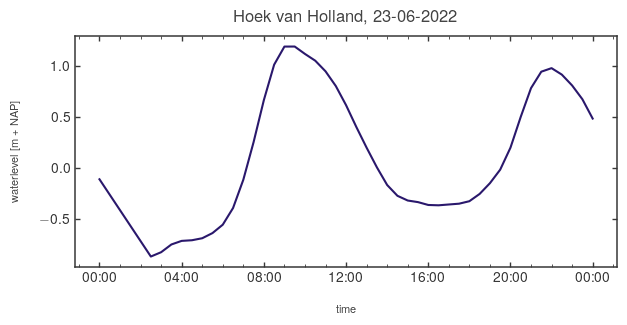

In [189]:
fig, ax = plt.subplots(FigureClass=GeneralPlot, figsize=(7,3))
plt.plot(uds['time'], uds['mesh2d_s1'].isel(mesh2d_nFaces=60701))
ax.set_xlabel('time')

# Extras and formatting
years = mdates.YearLocator()  # every year
months = mdates.MonthLocator()  # every month
days = mdates.DayLocator()
hours = mdates.HourLocator(interval=4)
hours_sm = mdates.HourLocator(interval=1)
minutes = mdates.MinuteLocator()
years_fmt = mdates.DateFormatter('%Y')
days_fmt = mdates.DateFormatter('%d-%m')
hours_fmt = mdates.DateFormatter('%H:%M')

# format the ticks
ax.xaxis.set_major_locator(hours)
ax.xaxis.set_major_formatter(hours_fmt)
ax.xaxis.set_minor_locator(hours_sm)

ax.format_xdata = mdates.DateFormatter('%H:%M')
ax.set_ylabel('waterlevel [m + NAP]')
ax.set_title('Hoek van Holland, 23-06-2022')

/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/geopandas/geodataframe.py:1640: DeprecationWarning: Passing a SingleBlockManager to Series is deprecated and will raise in a future version. Use public APIs instead.
  srs = pd.Series(*args, **kwargs)
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/geopandas/geodataframe.py:1640: DeprecationWarning: Passing a SingleBlockManager to Series is deprecated and will raise in a future version. Use public APIs instead.
  srs = pd.Series(*args, **kwargs)
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/pandas/core/frame.py:706: DeprecationWarning: Passing a BlockManager to GeoDataFrame is deprecated and will raise in a future version. Use public APIs instead.
  warnings.warn(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/geopandas/geodataframe.py:1640: DeprecationWarning: Passing a SingleBlockManager to Series is deprecated and will raise in a future version. Use publ

Text(0.5, 1.0, '2022/06/23 12:00, HWS')

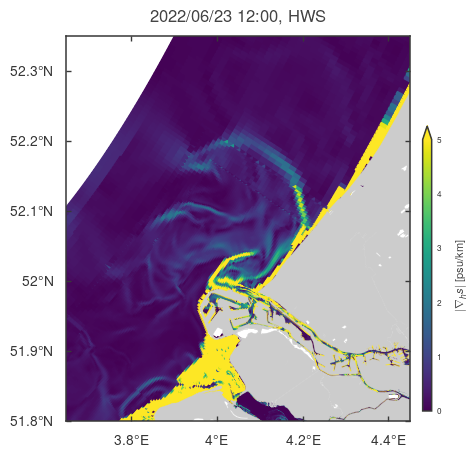

In [205]:
t = '2022/06/23 12:00'
fig, ax = plt.subplots(FigureClass=GeneralPlot, figsize=(6,5))
bg = plot_basic_background(ax=ax, crs='WGS84', zorder=1)
pc = (salinity_gradient_wgs84*1000).isel(mesh2d_nLayers=45).sel(time=t).ugrid.sel(y=slice(51.8, 52.4), x=slice(3.6, 4.5)).ugrid.plot(ax=ax,add_labels=False, add_colorbar=False, vmax=5, zorder=0)

# add colorbar
cax = fig.add_axes([ax.get_position().x1 + 0.01, ax.get_position().y0 + 0.02, 0.015, ax.get_position().height - 0.2])
cax.tick_params(axis=u'both', which=u'both', length=0)

# cbar limits + others
ax.set_ylim(51.8, 52.35)
ax.set_xlim(3.65, 4.45)
cb = plt.colorbar(pc, cax=cax, extend='max')
tracer_string = r'$|\nabla_h s|$ [psu/km]'
cb.set_label(f'{tracer_string}', labelpad=10, fontsize=8)
cb.ax.tick_params(labelsize=6) 
ax.set_title(f'{t}, HWS')

In [207]:
uds['mesh2d_u1']

<xarray.DataArray 'mesh2d_u1' (time: 45, mesh2d_nEdges: 259786,
                               mesh2d_nLayers: 46)>
dask.array<concatenate, shape=(45, 259786, 46), dtype=float64, chunksize=(1, 2985, 46), chunktype=numpy.ndarray>
Coordinates:
  * time           (time) datetime64[ns] 2022-06-23 ... 2022-06-24
    mesh2d_edge_x  (mesh2d_nEdges) float64 dask.array<chunksize=(2708,), meta=np.ndarray>
    mesh2d_edge_y  (mesh2d_nEdges) float64 dask.array<chunksize=(2708,), meta=np.ndarray>
  * mesh2d_nEdges  (mesh2d_nEdges) int64 0 1 2 3 ... 259782 259783 259784 259785
Dimensions without coordinates: mesh2d_nLayers
Attributes:
    mesh:           mesh2d
    location:       edge
    cell_methods:   mesh2d_nEdges: mean
    cell_measures:  area: mesh2d_au
    long_name:      Velocity at velocity point, n-component
    units:          m s-1
    grid_mapping:   projected_coordinate_system
    comment:        Positive direction is from first to second neighbouring f...

/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/distributed/client.py:3163: UserWarning: Sending large graph of size 30.72 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


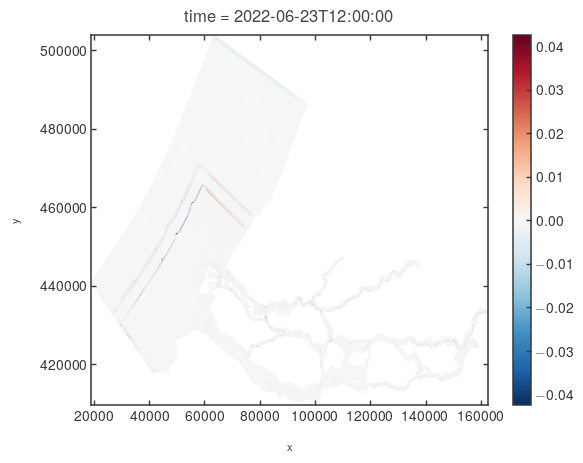

In [212]:
(div).isel(time=20, mesh2d_nLayers=45).ugrid.plot()

In [99]:
f = 2 * 7.2921E-5 * np.sin(np.deg2rad(51.92651))

In [100]:
f

0.00011480980225294851

In [86]:

def compute_divergence_on_face(constructorSVA, uda, **kwargs):
    # For this function, the vector on the edge needs to be in the direction of the normal vector!!
    
    from dfm_tools.xugrid_helpers import get_vertical_dimensions
    
    # > Obtain uds from constructorSVA object
    uds = constructorSVA.ds

    # > Get grid
    grid = uds.grid

    # > Get dimension and grid names
    dimn_maxfn = grid.to_dataset().mesh2d.attrs['max_face_nodes_dimension']
    dimn_faces = grid.face_dimension
    dimn_edges = grid.edge_dimension
    fill_value = grid.fill_value
    gridname = grid.name
    dimn_maxef = f'{gridname}_nMax_edge_faces'
    dimn_layer, dimn_interfaces = get_vertical_dimensions(uds)
    dimn_cart = f'{gridname}_nCartesian_coords'

    # > Determine varname from the provided array
    varname = uda.name

    # > Calculate the unit normal vectors if not in the dataset already
    try:
        unvs = kwargs['unvs']
    except:
        unvs = calculate_unit_normal_vectors(constructorSVA)
    
    # > Get the volume and flow area variables: check if they're in the 
    # > constructor first, then check the dataset, else throw error
    try:
        flow_area = constructorSVA.flow_area
    except:
        try:
            flow_area = uds[f'{gridname}_au'] # todo: extend to more arbitrary names in later stage
        except: 
            raise NameError('Could not retrieve the flow area, which is necessary for the gradient \
                             calculation. Please provide volume variable in the constructor or in the underlying dataset.')
    
    try:
        volume = constructorSVA.volume
    except:
        try:
            volume = uds[f'{gridname}_vol1']# todo: extend to more arbitrary names in later stage
        except:
            raise NameError('Could not retrieve the volume of the cells, which is necessary for the gradient \
                             calculation. Please provide volume variable in the constructor or in the underlying dataset.')

    # > Get the edge-face connectivity and replace fill values with -1
    edge_faces = xr.DataArray(uds.ugrid.grid.edge_face_connectivity, dims=(dimn_edges, dimn_maxef))
    edge_faces_validbool = edge_faces!=fill_value
    edge_faces = edge_faces.where(edge_faces_validbool, -1)
        
    # > Get the face-edge connectivity and replace fill values with -1
    face_edges = build_face_edge_connectivity(uds)
    face_edges_validbool = face_edges!=fill_value
    face_edges = face_edges.where(face_edges_validbool, -1)
    face_edges_stacked = face_edges.stack(__tmp_dim__=(dimn_faces, dimn_maxfn))

    # > Get the unit normal vectors (nf) also in the face-edges matrix
    fe_nfs = xr.where(face_edges!=fill_value, unvs.isel({dimn_edges:face_edges}), np.nan)

    # // 2. See if the normal vectors are pointing out of the cell. If not, flip them.
    # > Calculate distance vectors
    dv = calculate_distance_vectors(uds)
    # > Calculate the dot product between the calculated normal vectors and the distance vector for each face
    i_nfs = xr.dot(fe_nfs, dv, dims=[dimn_cart])
    # > if the product < 1, multiply by -1 to get an outwards facing normal vector, and update the variable
    fe_nfs = xr.where(i_nfs > 0, fe_nfs, fe_nfs * -1)
    
	# > Determine if we're looking at a velocity value u1 or u0
    # > Because these are vector quantities in the direction of the normal vector,
    # > to get to the final vector, we have to multiply u1/u0 by the normal vector
    # > first. Also, we need to check their sign for every edge.
    if dimn_edges in uda.dims:
        # > Make sure the edge dimension is not chunked, otherwise we will 
        # > get "PerformanceWarning: Slicing with an out-of-order index is generating x times more chunks."
        chunks = {dimn_edges:-1}
        uda = uda.chunk(chunks)

        # > Fill the face-edges matrix with the varname
        # > Do this via stack and unstack since 2D indexing does not
        # > properly work in dask yet: https://github.com/dask/dask/pull/10237
        edge_var_stacked = uda.isel({dimn_edges: face_edges_stacked})
        edge_var = edge_var_stacked.unstack("__tmp_dim__")
        # > Convert data-array back to an xu.UgridDataArray
        edge_var = xu.UgridDataArray(edge_var, grid=grid)

		# >> We have to determine the sign of the velocity 
		# >> Determine whether the u1 value is positive or negative
		# > Get the mesh2d_nFaces numbering of the 0th column in edge_faces (from
        # >  0 -> 1 is positive)
        pos_fe = xr.where(face_edges!=fill_value, edge_faces.isel({dimn_maxef:0}).isel({dimn_edges:face_edges}), fill_value)
        pos_fe = pos_fe.where(face_edges_validbool, -1)

		# > If the number of the 0th column in edge_faces == mesh2d_nFaces, then the 
        # > direction is already positive in the right direction.
		# > Otherwise, the direction needs to be flipped
        fe_multiplier = xr.where(pos_fe==uds[dimn_faces], 1, -1)
        edge_var = edge_var * fe_multiplier

        # > Calculate the dot product of the vector quantity with the unit normal vectors
        edge_var = dot_product(edge_var, fe_nfs, dim=dimn_cart) 

        # > Fill face_edge matrix with flow area data
        flow_area = flow_area.chunk(chunks)
        edge_au_stacked = flow_area.isel({dimn_edges:face_edges_stacked})
        edge_au = edge_au_stacked.unstack("__tmp_dim__")
        
        # > Multiply the variable with the edge area (flow area), multiply by the 
        # > "flipped boolean" and the unit normal vector, and sum (dimension: faces)
        face_vars = (edge_var * edge_au).sum(dim=dimn_maxfn, keep_attrs=True)
        
        # > Multiply the total result with (1/cell volume) (dimension: faces)
        uds[f'{varname}_divergence'] = divergence = ((1/volume) * face_vars).sum(dim=dimn_cart)
        
        return divergence

    else: 
        raise ValueError('This function only supports the calculation of the divergence at face location, \
                         based on data on edges. Please supply a variable that is located on the edges.')
